# Probe vs BiMamba (W2V) — scatter na MoM

## Co sprawdzamy?

Na **tych samych** plikach MoM (`preprocessed_pooled_fp16`) porównujemy dwa score’y:

| Metoda | Pipeline |
|--------|----------|
| **Probe** | `mean(W2V)` → StandardScaler → LogisticRegression (uczony na Sonics train) |
| **BiMamba only_w2v** | `[1500, 2048]` → model bierze `[:, :1024]` → BiMamba → mean → logit |

## Po co?

1. **Korelacja** — czy modele widzą to samo (r>0.8) czy zupełnie inaczej (bug / zły ckpt)?
2. **EER na tych samych etykietach** — probe ~0.13 vs BiMamba ~0.22 — czy rozjazd jest systematyczny?
3. **Wykres scatter** — gdzie się mylimy (fałszywe alarmy vs przeoczenia)?
4. **Werdykt** — problem w **Mambii/treningu** vs **błąd eval/ckpt**

**Ustaw `CKPT_PATH`** na checkpoint `bimamba-only-w2v` przed uruchomieniem inferencji.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torchmetrics.classification import EER
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torchmetrics.classification import EER
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.models.mamba import BidirectionalMambaModel
from src.utils.dataset import parse_split_label, parse_split_label_mom

SCRATCH = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data")
SONICS_POOLED = SCRATCH / "Sonics/preprocessed_pooled_fp16"
MOM_POOLED = SCRATCH / "MoM/preprocessed_pooled_fp16"
CACHE_DIR = ROOT / "notebooks" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# === UZUPEŁNIJ: ścieżka do only_w2v checkpoint (.ckpt) ===
CKPT_PATH = "/net/people/plgrid/plgjedrzejkusnierz/big_storage/SVDD/outputs/2026-06-01/19-01-48/bimamba-only-w2v/checkpoints/epoch=017-val_loss=0.0000.ckpt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
RANDOM_SEED = 42
W2V_DIM = 1024

In [3]:
# Pomoc: znajdź checkpointi only_w2v w outputs/
outputs = ROOT / "outputs"
if outputs.exists():
    ckpts = sorted(outputs.rglob("*.ckpt"))
    only_w2v = [p for p in ckpts if "only-w2v" in str(p) or "only_w2v" in str(p)]
    print(f"Znaleziono {len(only_w2v)} ckpt z 'only-w2v' w ścieżce:")
    for p in only_w2v[:10]:
        print(" ", p)
    if len(only_w2v) > 10:
        print("  ...")
else:
    print("Brak katalogu outputs/ — ustaw CKPT_PATH ręcznie")

Znaleziono 4 ckpt z 'only-w2v' w ścieżce:
  /net/pr2/projects/plgrid/plggaudiodfpwr/SVDD/outputs/2026-06-01/19-01-48/bimamba-only-w2v/checkpoints/epoch=017-val_loss=0.0000.ckpt
  /net/pr2/projects/plgrid/plggaudiodfpwr/SVDD/outputs/2026-06-01/19-01-48/bimamba-only-w2v/checkpoints/last.ckpt
  /net/pr2/projects/plgrid/plggaudiodfpwr/SVDD/outputs/2026-06-02/19-12-35/bimamba-only-w2v-layer-norm/checkpoints/epoch=004-val_loss=0.0000.ckpt
  /net/pr2/projects/plgrid/plggaudiodfpwr/SVDD/outputs/2026-06-02/19-12-35/bimamba-only-w2v-layer-norm/checkpoints/last.ckpt


In [4]:
def find_index(data_dir: Path) -> Path:
    matches = list(data_dir.rglob("index.json"))
    if not matches:
        raise FileNotFoundError(f"Brak index.json w {data_dir}")
    return matches[0]


def load_index_entries(data_dir: Path, parse_label, splits=None) -> list[dict]:
    with open(find_index(data_dir), encoding="utf-8") as f:
        data = json.load(f)
    entries = []
    for item in data:
        stem, pooled = item.get("stem"), item.get("pooled")
        if not stem or not pooled:
            continue
        split, label = parse_label(stem)
        if splits is not None and split not in splits:
            continue
        entries.append({"stem": stem, "label": label, "path": pooled})
    return entries


def pooled_w2v_mean(path) -> np.ndarray:
    x = np.load(path).astype(np.float32)
    return x[:, :W2V_DIM].mean(axis=0)


def build_matrix(entries, cache_key=None):
    if cache_key:
        cache_path = CACHE_DIR / f"{cache_key}.npz"
        if cache_path.exists():
            d = np.load(cache_path)
            return d["X"], d["y"], [e["stem"] for e in entries]
    X = np.stack([pooled_w2v_mean(e["path"]) for e in tqdm(entries, desc="w2v mean")])
    y = np.array([e["label"] for e in entries], dtype=np.int64)
    stems = [e["stem"] for e in entries]
    if cache_key:
        np.savez(CACHE_DIR / f"{cache_key}.npz", X=X, y=y)
    return X, y, stems


def eer_score(probs: np.ndarray, y: np.ndarray) -> float:
    eer = EER(task="binary")
    return float(eer(torch.tensor(probs, dtype=torch.float32), torch.tensor(y, dtype=torch.int64)))


def metrics_at_05(probs, y):
    pred = (probs >= 0.5).astype(int)
    return {
        "eer": eer_score(probs, y),
        "f1": f1_score(y, pred, zero_division=0),
    }

## 1. Linear probe (Sonics train → score MoM)

In [5]:
sonics_train = load_index_entries(SONICS_POOLED, parse_split_label, splits={"train"})
mom_entries = load_index_entries(MOM_POOLED, parse_split_label_mom)
print(f"Sonics train: {len(sonics_train)}, MoM: {len(mom_entries)}")

X_train, y_train, _ = build_matrix(sonics_train, cache_key="scatter_sonics_w2v_train")
X_mom, y_mom, stems_mom = build_matrix(mom_entries, cache_key="scatter_mom_w2v")

probe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
])
probe.fit(X_train, y_train)
probe_probs = probe.predict_proba(X_mom)[:, 1]

probe_m = metrics_at_05(probe_probs, y_mom)
print("Probe MoM:", probe_m)

Sonics train: 64050, MoM: 1098
Probe MoM: {'eer': 0.12570902705192566, 'f1': 0.8472095150960659}


## 2. BiMamba only_w2v (checkpoint → score MoM)

In [2]:
import torch
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
print("DEVICE =", DEVICE)

cuda available: True
device: Tesla V100-SXM2-32GB
DEVICE = cuda


In [6]:
def load_bimamba_only_w2v(ckpt_path: Path) -> BidirectionalMambaModel:
    model = BidirectionalMambaModel.load_from_checkpoint(
        str(ckpt_path),
        map_location="cpu",
        strict=False,
    )
    model.eval()
    model.to(DEVICE)
    om = getattr(model, "only_modality", None)
    print(f"only_modality={om!r}, norm_type={getattr(model, 'norm_type', None)!r}")
    if om != "w2v":
        print("UWAGA: checkpoint może nie być only_w2v — sprawdź CKPT_PATH i eval config!")
    return model


@torch.no_grad()
def score_mom_bimamba(model, entries, batch_size=BATCH_SIZE) -> np.ndarray:
    probs = []
    paths = [e["path"] for e in entries]
    for i in tqdm(range(0, len(paths), batch_size), desc="BiMamba infer"):
        batch_paths = paths[i : i + batch_size]
        xs = [torch.from_numpy(np.load(p).astype(np.float32)) for p in batch_paths]
        x = torch.stack(xs).to(DEVICE)  # [B, 1500, 2048]
        logits = model(x).squeeze(-1)
        probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)


if CKPT_PATH is None or not Path(CKPT_PATH).exists():
    print("Pomiń BiMamba: ustaw CKPT_PATH w komórce konfiguracji.")
    bimamba_probs = None
else:
    model = load_bimamba_only_w2v(Path(CKPT_PATH))
    bimamba_probs = score_mom_bimamba(model, mom_entries)
    bimamba_m = metrics_at_05(bimamba_probs, y_mom)
    print("BiMamba only_w2v MoM:", bimamba_m)

only_modality='w2v', norm_type='none'


BiMamba infer:   0%|          | 0/69 [00:00<?, ?it/s]

BiMamba only_w2v MoM: {'eer': 0.21769565343856812, 'f1': 0.7839673913043478}


## 3. Scatter + korelacja + rozjazdy

Pearson r  = 0.4717
Spearman r = 0.5868
Disagreements @0.5: 409 / 1098 (37.2%)


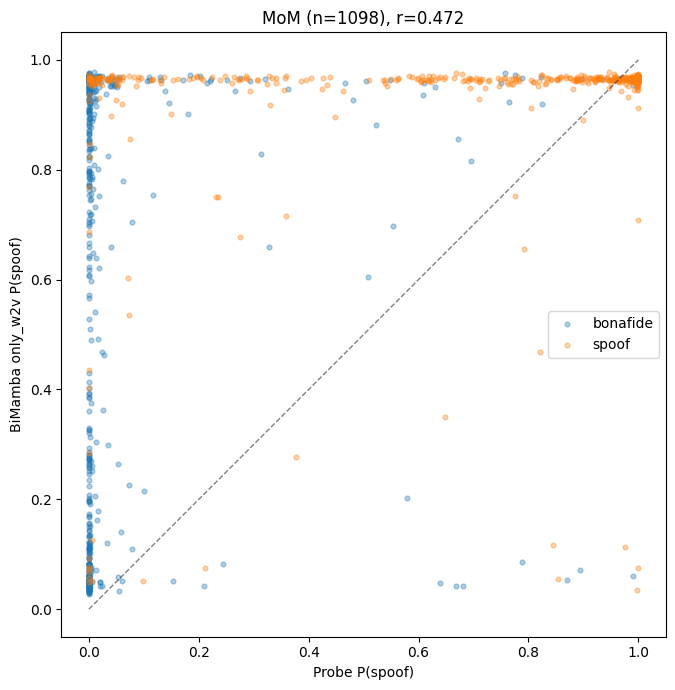


=== Metryki (te same etykiety MoM) ===
              model       eer        f1
0             probe  0.125709  0.847210
1  bimamba_only_w2v  0.217696  0.783967


In [7]:
df = pd.DataFrame({
    "stem": stems_mom,
    "label": y_mom,
    "probe": probe_probs,
})
if bimamba_probs is not None:
    df["bimamba"] = bimamba_probs
    df["probe_pred"] = (df["probe"] >= 0.5).astype(int)
    df["bimamba_pred"] = (df["bimamba"] >= 0.5).astype(int)
    df["disagree"] = df["probe_pred"] != df["bimamba_pred"]

    r_p, _ = pearsonr(df["probe"], df["bimamba"])
    r_s, _ = spearmanr(df["probe"], df["bimamba"])
    print(f"Pearson r  = {r_p:.4f}")
    print(f"Spearman r = {r_s:.4f}")
    print(f"Disagreements @0.5: {df['disagree'].sum()} / {len(df)} ({100*df['disagree'].mean():.1f}%)")

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    bonafide = df["label"] == 0
    ax.scatter(df.loc[bonafide, "probe"], df.loc[bonafide, "bimamba"], alpha=0.35, s=12, label="bonafide", c="C0")
    ax.scatter(df.loc[~bonafide, "probe"], df.loc[~bonafide, "bimamba"], alpha=0.35, s=12, label="spoof", c="C1")
    lims = [0, 1]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
    ax.set_xlabel("Probe P(spoof)")
    ax.set_ylabel("BiMamba only_w2v P(spoof)")
    ax.set_title(f"MoM (n={len(df)}), r={r_p:.3f}")
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    print("\n=== Metryki (te same etykiety MoM) ===")
    print(pd.DataFrame([
        {"model": "probe", **probe_m},
        {"model": "bimamba_only_w2v", **bimamba_m},
    ]))
else:
    print("Brak scoreów BiMamba — tylko probe:")
    print(probe_m)

## 4. Jak czytać wynik

| Obserwacja | Interpretacja |
|------------|----------------|
| **r > 0.85**, podobny EER | Ten sam sygnał, głównie różna kalibracja — Mamba nie jest „głupia”, może tuning progu/head |
| **r wysokie, EER BiMamba dużo gorszy** | Systematyczne przesunięcie (bias) — np. overconfidence na spoof |
| **r niskie (<0.5)** | Inna informacja lub **zły ckpt / zły model w eval** — szukaj buga |
| Dużo `disagree` na spoof | BiMamba przeoczenia lub probe fałszywe alarmy — zobacz tabelę poniżej |

Probe baseline MoM EER ~**0.126** (z `linear_probe.ipynb`). Jeśli BiMamba ~**0.22** przy r>0.8 → problem raczej **głowy/kalibracji** niż braku sygnału w W2V.

In [8]:
if bimamba_probs is not None:
    # Największe rozjazdy (probe vs bimamba)
    df["abs_diff"] = (df["probe"] - df["bimamba"]).abs()
    cols = ["stem", "label", "probe", "bimamba", "probe_pred", "bimamba_pred", "abs_diff"]
    print("Top rozjazdy (|probe - bimamba|):")
    display(df.sort_values("abs_diff", ascending=False).head(15)[cols])

    # Probe dobrze, BiMamba źle (spoof jako bonafide)
    bad = df[(df["label"] == 1) & (df["probe_pred"] == 1) & (df["bimamba_pred"] == 0)]
    print(f"\nSpoof: probe OK, BiMamba missed (FN BiMamba): {len(bad)}")
    display(bad.head(10)[cols])

Top rozjazdy (|probe - bimamba|):


,stem,label,probe,bimamba,probe_pred,bimamba_pred,abs_diff
435,bonafide_real_00647,0,2.073192e-05,0.976137,0,1,0.976116
850,bonafide_real_00620,0,6.443670e-04,0.976717,0,1,0.976073
995,bonafide_real_00334,0,6.071177e-04,0.973666,0,1,0.973059
322,bonafide_real_00118,0,1.479632e-06,0.972372,0,1,0.972371
706,bonafide_real_00072,0,5.508072e-04,0.972439,0,1,0.971888
874,deepfake_diffrythm_068_diffrythm_1059,1,3.408188e-05,0.971590,0,1,0.971556
760,bonafide_real_00183,0,5.609075e-04,0.971929,0,1,0.971368
931,bonafide_real_00404,0,1.703118e-04,0.971427,0,1,0.971257
16,bonafide_real_00341,0,2.563355e-04,0.971485,0,1,0.971229
483,bonafide_real_00207,0,3.117163e-05,0.971068,0,1,0.971037



Spoof: probe OK, BiMamba missed (FN BiMamba): 7


,stem,label,probe,bimamba,probe_pred,bimamba_pred,abs_diff
56,deepfake_udio_079_udio_1_5_10068,1,0.845346,0.116510,1,0,0.728837
85,deepfake_suno_suno_3_metadata_140_d44c2a65-3cd...,1,0.997451,0.035380,1,0,0.962071
347,deepfake_suno_suno_2_metadata_012_f6d63211-813...,1,0.975536,0.113261,1,0,0.862275
613,deepfake_yue_010_yue_1006,1,0.999986,0.074855,1,0,0.925132
680,deepfake_diffrythm_044_diffrythm_1037,1,0.853544,0.054738,1,0,0.798806
932,deepfake_suno_suno_2_metadata_034_9e1c7982-15c...,1,0.648962,0.350116,1,0,0.298846
1004,deepfake_suno_suno_2_metadata_015_55466b95-a0a...,1,0.820732,0.468475,1,0,0.352257
